In [12]:
import flox  
import geopandas as gpd
import icechunk
import numpy as np
import pandas as pd
import pooch
import xarray as xr
import xproj  
from rasterix.rasterize import geometry_clip

import matplotlib.pyplot as plt

from srm import catalog
from srm.analysis import BCSDRun, load_nasa_nex
from srm.bcsd_config import BCSDConfig, VariableConfig
from srm.plotting import (
    calculate_statistic_to_plot,
    get_4_subregions,
    locations,
    plot_4regions_comparisons,
    plot_comparisons,
    plot_timeseries,
    prep_datasets_for_seasonal_cycle_plotting,
    random_non_leap_year,
)

import time
import numpy as np
import xarray as xr
import icechunk
import dask
import xarray_regrid
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.lines as mlines

from srm.downscaling_utils import rechunk

In [26]:
import xarray as xr
import icechunk

BUCKET     = "carbonplan-srm"
REGION     = "us-west-2"
BRANCH     = "v0.12.0"
VARIABLES  = ("tas", "pr", "hurs", "rsds", "tasmin", "tasmax")

STORE_TMPL = ("s3://us-west-2.opendata.source.coop/carbonplan/srm-downscaling/"
              "output/production/{gcm}-ERA5-global.icechunk")

#other models other than cesm are not published yet?
MODELS = {
    "CESM2-WACCM": STORE_TMPL.format(gcm="CESM2-WACCM"),
    "MIROC6":      STORE_TMPL.format(gcm="MIROC-ES2H"),
    "UKESM1-0-LL": STORE_TMPL.format(gcm="UKESM"),
}

SCENARIOS = {
    "ssp245":  "008",
    "g6_1p5k": "003",
}


def _parse_s3(path):
    """'s3://bucket/a/b/c' -> ('bucket', 'a/b/c')"""
    bucket, _, prefix = path.removeprefix("s3://").partition("/")
    return bucket, prefix.strip("/")


def load_downscaled(scenario, ens, gcm, variables=VARIABLES,
                    branch=BRANCH, coarse=False):
    """Open the downscaled icechunk store for one model / scenario / ensemble member."""
    bucket, prefix = _parse_s3(MODELS[gcm])
    storage = icechunk.s3_storage(bucket=bucket, prefix=prefix,
                                  anonymous=True, region=REGION)
    session = icechunk.Repository.open(storage).readonly_session(branch=branch)
    stem = f"debiased_coarse/{scenario}" if coarse else scenario

    das = []
    for var in variables:
        ds = xr.open_dataset(session.store, engine="zarr",
                             group=f"{stem}/{var}/{ens}", chunks={})
        das.append(ds[var].drop_vars("dayofyear", errors="ignore"))
    return xr.merge(das, join="outer")


def load_raw(scenario, ens, gcm, variables=VARIABLES):
    """Open the raw GCM store for one model / scenario / ensemble member."""
    return (
        catalog.get(gcm)
        .to_xarray(group=scenario)
        [list(variables)]
        .sel(ensemble_member=ens)
    )

In [32]:
GCM = "CESM2-WACCM"
testing_period = slice("2069-01-01", "2069-12-31")

ds  = {s: load_downscaled(s, e, GCM).sel(time=testing_period) for s, e in SCENARIOS.items()}
raw = {s: load_raw(s, e, GCM).sel(time=testing_period)        for s, e in SCENARIOS.items()}

In [33]:
import xarray_regrid
from srm.downscaling_utils import rechunk


def fine_to_coarse(ds_fine, ds_coarse_grid):
    target = ds_coarse_grid.reset_coords(drop=True)
    return ds_fine.regrid.conservative(target, latitude_coord="lat")


def rechunk_ds(ds, pattern="full_space"):
    return xr.merge([rechunk(ds[v], pattern=pattern) for v in VARIABLES])


coarsened = {s: fine_to_coarse(rechunk_ds(ds[s]), raw[s]) for s in SCENARIOS}

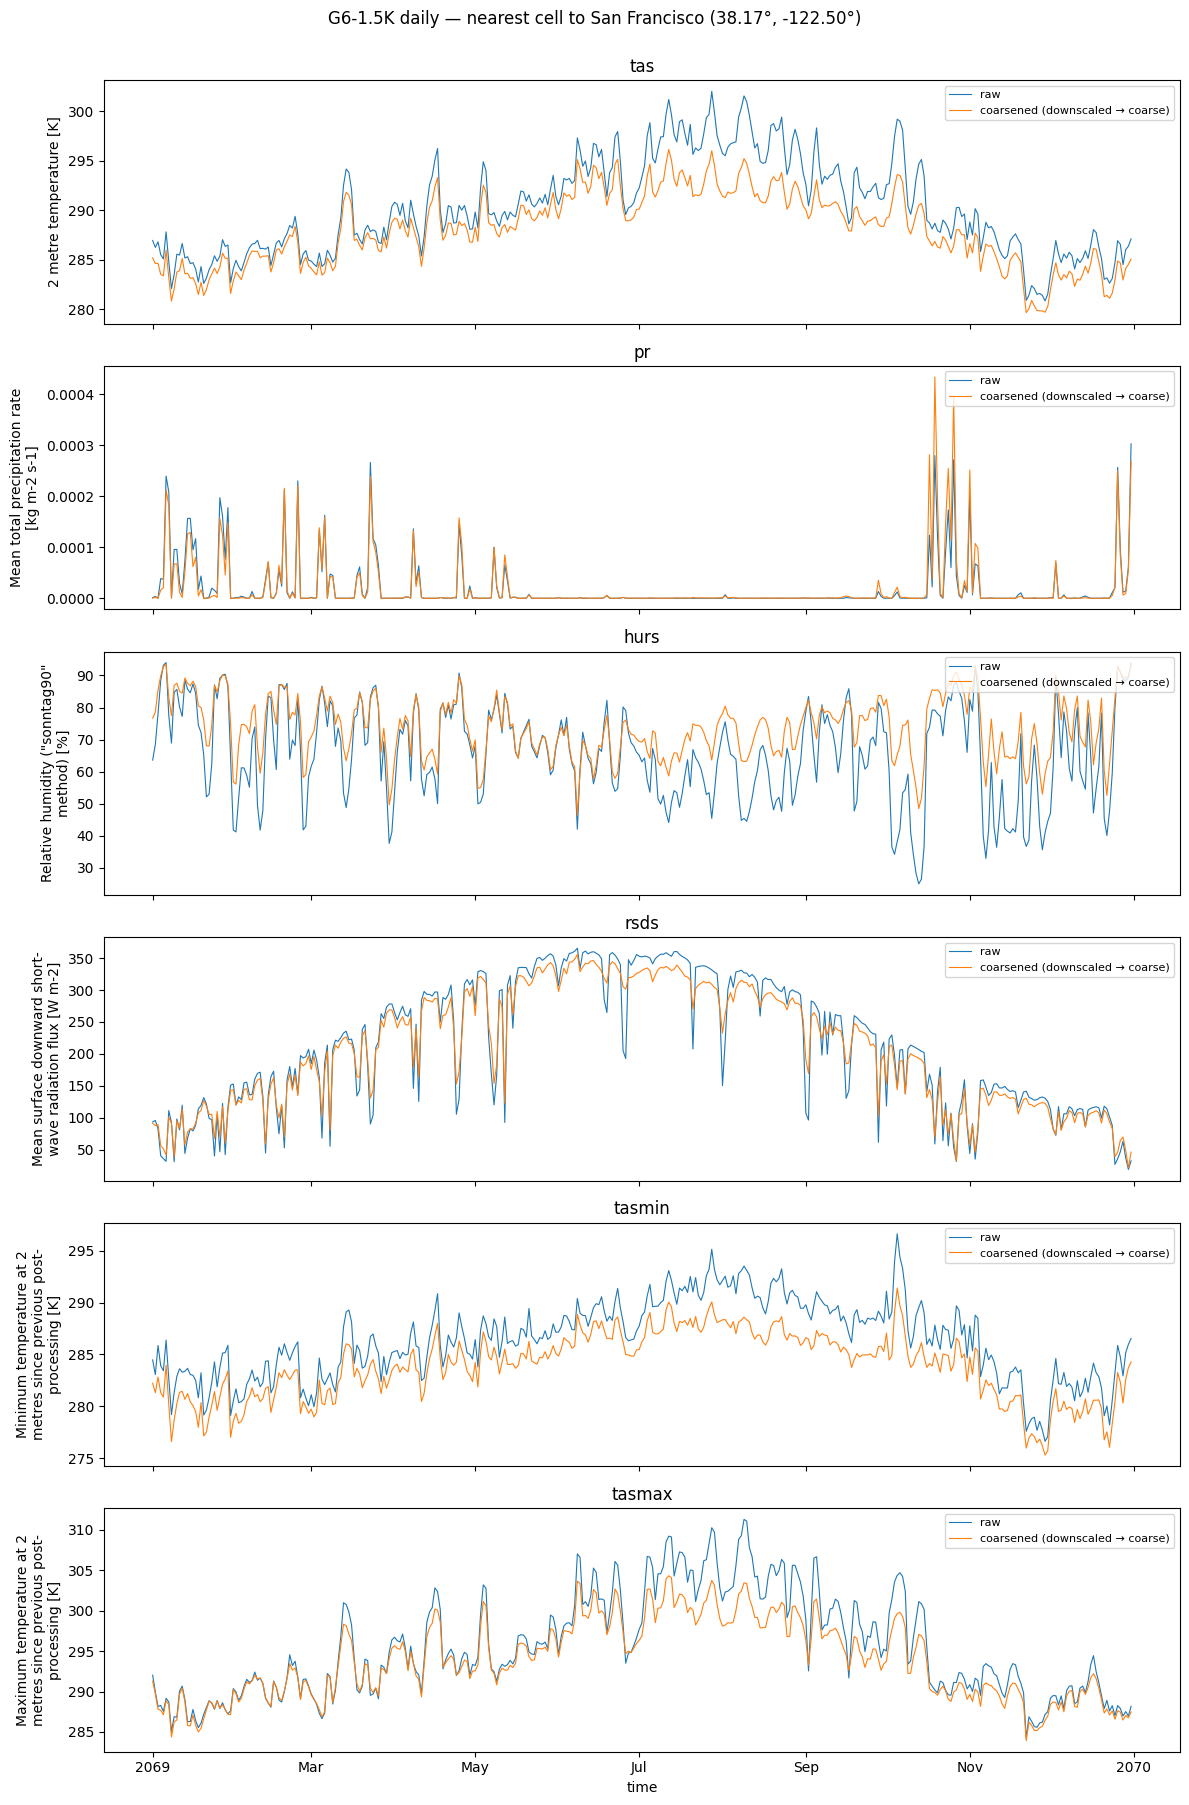

In [34]:
import matplotlib.pyplot as plt

SF_LAT, SF_LON = 37.77, -122.42

def nearest_sf(ds):
    lon = SF_LON % 360 if float(ds.lon.max()) > 180 else SF_LON  # handle 0–360 grids
    return ds.sel(lat=SF_LAT, lon=lon, method="nearest")

raw_sf    = nearest_sf(raw["g6_1p5k"])
coarse_sf = nearest_sf(coarsened["g6_1p5k"])

fig, axes = plt.subplots(len(VARIABLES), 1, figsize=(12, 3 * len(VARIABLES)),
                         sharex=True)

for ax, var in zip(axes, VARIABLES):
    raw_sf[var].plot(ax=ax, label="raw", lw=0.8)
    coarse_sf[var].plot(ax=ax, label="coarsened (downscaled → coarse)", lw=0.8)
    ax.set_title(var)
    ax.set_xlabel("")
    ax.legend(loc="upper right", fontsize=8)

axes[-1].set_xlabel("time")
fig.suptitle(
    f"G6-1.5K daily — nearest cell to San Francisco "
    f"({float(raw_sf.lat):.2f}°, {float(raw_sf.lon):.2f}°)",
    y=1.0,
)
plt.tight_layout()
plt.show()